In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

class DecisionTree:
    """
    Decision Tree Classifier from scratch.
    Uses Gini impurity for splitting.
    """
    
    def __init__(self, max_depth=5, min_samples_split=2, min_gain=1e-7, verbose=False):
        """
        Parameters:
        -----------
        max_depth : int
            Maximum depth of the tree
        min_samples_split : int
            Minimum number of samples required to split a node
        min_gain : float
            Minimum information gain required for a split
        verbose : bool
            Whether to print progress
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_gain = min_gain
        self.verbose = verbose
        self.tree_ = None
        self.feature_importances_ = None

    def _gini(self, y):
        """Compute Gini impurity."""
        m = len(y)
        if m == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        p = counts / m
        return 1 - np.sum(p ** 2)

    def _best_split(self, X, y):
        """Find best feature and threshold using sorted values and incremental updates."""
        m, n = X.shape
        if m <= 1:
            return None, None, 0

        parent_gini = self._gini(y)
        best_gain, best_feat, best_thresh = 0, None, None
        classes = np.unique(y)

        # Iterate over each feature
        for feat in range(n):
            # Sort by this feature
            sorted_idx = np.argsort(X[:, feat])
            X_sorted = X[sorted_idx, feat]
            y_sorted = y[sorted_idx]

            # Initialize class counts
            left_counts = {c: 0 for c in classes}
            right_counts = {c: np.sum(y == c) for c in classes}
            left_size, right_size = 0, m

            # Move threshold from left to right
            for i in range(1, m):
                c = y_sorted[i - 1]
                left_counts[c] += 1
                right_counts[c] -= 1
                left_size += 1
                right_size -= 1

                # Skip identical feature values (no real threshold)
                if X_sorted[i] == X_sorted[i - 1]:
                    continue

                # Compute Gini for left and right
                g_left = 1 - sum((left_counts[c] / left_size) ** 2 for c in classes if left_size > 0)
                g_right = 1 - sum((right_counts[c] / right_size) ** 2 for c in classes if right_size > 0)

                # Weighted average of child impurities
                gain = parent_gini - (left_size / m) * g_left - (right_size / m) * g_right

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = (X_sorted[i] + X_sorted[i - 1]) / 2  # midpoint

        if best_gain < self.min_gain:
            return None, None, 0
        return best_feat, best_thresh, best_gain

    def _build(self, X, y, idx, depth, feature_importances=None):
        """Recursively build the decision tree using index references (no slicing)."""
        y_subset = y[idx]
        
        if (depth >= self.max_depth or 
            len(y_subset) < self.min_samples_split or 
            len(np.unique(y_subset)) == 1):
            vals, counts = np.unique(y_subset, return_counts=True)
            return vals[np.argmax(counts)]

        feat, thresh, gain = self._best_split(X[idx], y_subset)
        
        # Update feature importances
        if feature_importances is not None and feat is not None:
            feature_importances[feat] += gain * len(y_subset)
        
        if feat is None:
            vals, counts = np.unique(y_subset, return_counts=True)
            return vals[np.argmax(counts)]

        left_idx = idx[X[idx, feat] <= thresh]
        right_idx = idx[X[idx, feat] > thresh]

        if len(left_idx) == 0 or len(right_idx) == 0:
            vals, counts = np.unique(y_subset, return_counts=True)
            return vals[np.argmax(counts)]

        left_tree = self._build(X, y, left_idx, depth + 1, feature_importances)
        right_tree = self._build(X, y, right_idx, depth + 1, feature_importances)
        return (feat, thresh, left_tree, right_tree)

    def fit(self, X, y):
        """Train the decision tree."""
        X = np.asarray(X)
        y = np.asarray(y)
        
        if self.verbose:
            print(f"Training Decision Tree: max_depth={self.max_depth}, min_samples_split={self.min_samples_split}")
        
        # Initialize feature importances
        self.feature_importances_ = np.zeros(X.shape[1])
        
        idx = np.arange(len(y))
        self.tree_ = self._build(X, y, idx, 0, self.feature_importances_)
        
        # Normalize feature importances
        total_importance = self.feature_importances_.sum()
        if total_importance > 0:
            self.feature_importances_ /= total_importance
        
        if self.verbose:
            print(f"✓ Training completed")
        
        return self

    def _predict_one(self, x, node):
        """Predict a single sample."""
        if not isinstance(node, tuple):
            return node
        feat, thresh, left, right = node
        if x[feat] <= thresh:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

    def predict(self, X):
        """Predict class labels."""
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree_) for x in X])
    
    def get_depth(self, node=None, current_depth=0):
        """Get the maximum depth of the tree."""
        if node is None:
            node = self.tree_
        
        if not isinstance(node, tuple):
            return current_depth
        
        _, _, left, right = node
        left_depth = self.get_depth(left, current_depth + 1)
        right_depth = self.get_depth(right, current_depth + 1)
        return max(left_depth, right_depth)

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import os

# Custom SMOTE implementation (memory-efficient, avoids dependency issues)
class SimpleSMOTE:
    """Simple SMOTE implementation with memory optimization"""
    def __init__(self, k_neighbors=5, random_state=42, max_samples_per_class=None):
        self.k = k_neighbors
        self.random_state = np.random.RandomState(random_state)
        self.max_samples_per_class = max_samples_per_class
    
    def fit_resample(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)
        classes, counts = np.unique(y, return_counts=True)
        max_count = counts.max()
        
        if self.max_samples_per_class is not None:
            max_count = min(max_count, self.max_samples_per_class)
        
        X_resampled = [X]
        y_resampled = [y]
        
        for cls, count in zip(classes, counts):
            X_cls = X[y == cls]
            if count < max_count:
                n_samples_needed = max_count - count
                synthetic_samples = self._generate_samples(X_cls, n_samples_needed)
                X_resampled.append(synthetic_samples.astype(np.float32))
                y_resampled.append(np.full(n_samples_needed, cls))
        
        X_res = np.vstack(X_resampled).astype(np.float32)
        y_res = np.concatenate(y_resampled)
        return X_res, y_res
    
    def _generate_samples(self, X, n_samples):
        n_minority = len(X)
        if n_minority == 0:
            return np.empty((0, X.shape[1]), dtype=np.float32)
        k = min(self.k, n_minority - 1)
        synthetic = []
        for _ in range(n_samples):
            i = self.random_state.randint(0, n_minority)
            xi = X[i]
            distances = np.sqrt(((X - xi)**2).sum(axis=1))
            nn_indices = np.argsort(distances)[1:k+1]
            nn = X[self.random_state.choice(nn_indices)]
            diff = nn - xi
            gap = self.random_state.rand()
            synthetic.append(xi + gap * diff)
        return np.array(synthetic, dtype=np.float32)

# Load and prepare data
data = None

try:
    data = pd.read_csv("city_day.csv")
except FileNotFoundError:
    try:
        data = pd.read_csv("city_day_dataset.csv")
    except FileNotFoundError:
        raise FileNotFoundError("Dataset file not found")

# Convert Date to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Handle missing values - Memory efficient approach
numeric_columns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
                   'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for col in numeric_columns:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

if 'AQI_Bucket' in data.columns:
    data['AQI_Bucket'] = data['AQI_Bucket'].fillna('Moderate')

# Encode categorical variables
le = LabelEncoder()
city_encoder = LabelEncoder()
data['City'] = city_encoder.fit_transform(data['City'].astype(str))
data['AQI_Bucket'] = le.fit_transform(data['AQI_Bucket'].astype(str))

# Prepare features
feature_columns = ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 
                   'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
feature_columns = [col for col in feature_columns if col in data.columns]
X = data[feature_columns].values
y = data['AQI_Bucket'].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Apply SMOTE for data balancing with memory limits
MAX_SAMPLES_PER_CLASS = 3000  # Memory limit
smote = SimpleSMOTE(random_state=42, max_samples_per_class=MAX_SAMPLES_PER_CLASS)

try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
except MemoryError:
    X_train_smote, y_train_smote = X_train, y_train

# Convert to float32 to save memory
X_train_smote = X_train_smote.astype(np.float32)
X_test = X_test.astype(np.float32)

# Further reduce dataset if too large
MAX_TRAIN_SAMPLES = 10000
if len(X_train_smote) > MAX_TRAIN_SAMPLES:
    X_train_smote, _, y_train_smote, _ = train_test_split(
        X_train_smote, y_train_smote,
        train_size=MAX_TRAIN_SAMPLES,
        random_state=42,
        stratify=y_train_smote
    )

# Scale features
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
print("  ✓ Features scaled")
print("\n" + "="*80)
print("✅ DATA PREPARATION COMPLETE")
print("="*80)
print(f"  Train samples: {X_train_smote.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features: {X_train_smote.shape[1]}")
print(f"  Feature columns: {feature_columns}")
print(f"  Classes: {le.classes_}")
print(f"  Number of classes: {len(le.classes_)}")
print(f"  Memory optimization: Using float32, limited samples")
print("="*80 + "\n")


  ✓ Features scaled

✅ DATA PREPARATION COMPLETE
  Train samples: 10000
  Test samples: 8860
  Features: 13
  Feature columns: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']
  Number of classes: 6
  Memory optimization: Using float32, limited samples



In [4]:
# Train the Decision Tree model
print("\n" + "="*80)
print("TRAINING DECISION TREE MODEL")
print("="*80)

# Hyperparameters (you can tune these)
max_depth = 10
min_samples_split = 5

print(f"\n📊 Training Configuration:")
print(f"  max_depth: {max_depth}")
print(f"  min_samples_split: {min_samples_split}")
print(f"  Training samples: {len(X_train_smote)}")
print(f"  Number of classes: {len(np.unique(y_train_smote))}")

# Create and train model
model = DecisionTree(
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    verbose=True
)

print(f"\n🚀 Starting training...")
model.fit(X_train_smote, y_train_smote)

# Get tree information
actual_depth = model.get_depth()
print(f"\n🌳 Tree Information:")
print(f"  Maximum depth (configured): {max_depth}")
print(f"  Actual tree depth: {actual_depth}")
print(f"  Number of features: {len(feature_columns)}")

print("\n✅ Training completed!")


TRAINING DECISION TREE MODEL

📊 Training Configuration:
  max_depth: 10
  min_samples_split: 5
  Training samples: 10000
  Number of classes: 6

🚀 Starting training...
Training Decision Tree: max_depth=10, min_samples_split=5
✓ Training completed

🌳 Tree Information:
  Maximum depth (configured): 10
  Actual tree depth: 10
  Number of features: 13

✅ Training completed!



MODEL EVALUATION

📊 Making predictions...

OVERALL METRICS
  Accuracy:  0.7764 (77.64%)
  Precision: 0.7821 (78.21%)
  Recall:    0.7764 (77.64%)
  F1-Score:  0.7784 (77.84%)

PER-CLASS METRICS


       Class  Precision   Recall  F1-Score
        Good   0.568047 0.732824  0.640000
    Moderate   0.854966 0.817586  0.835858
        Poor   0.605033 0.657551  0.630199
Satisfactory   0.776082 0.776082  0.776082
      Severe   0.723150 0.795276  0.757500
   Very Poor   0.740122 0.692745  0.715650

DETAILED CLASSIFICATION REPORT


              precision    recall  f1-score   support

        Good       0.57      0.73      0.64       393
    Moderate       0.85      0.82      0.84      4117
        Poor       0.61      0.66      0.63       841
Satisfactory       0.78      0.78      0.78      2425
      Severe       0.72      0.80      0.76       381
   Very Poor       0.74      0.69      0.72       703

    accuracy                           0.78      8860
   macro avg       0.71      0.75 

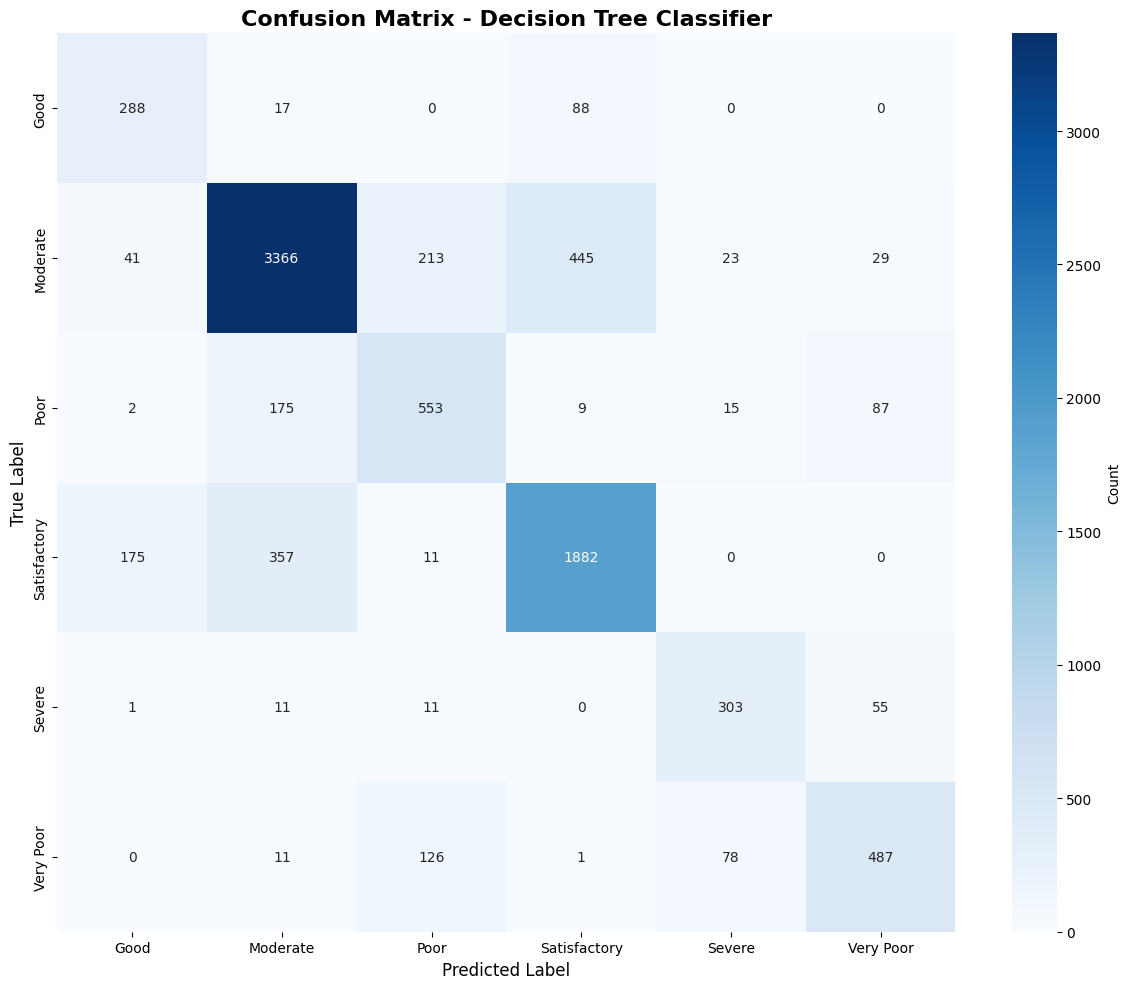

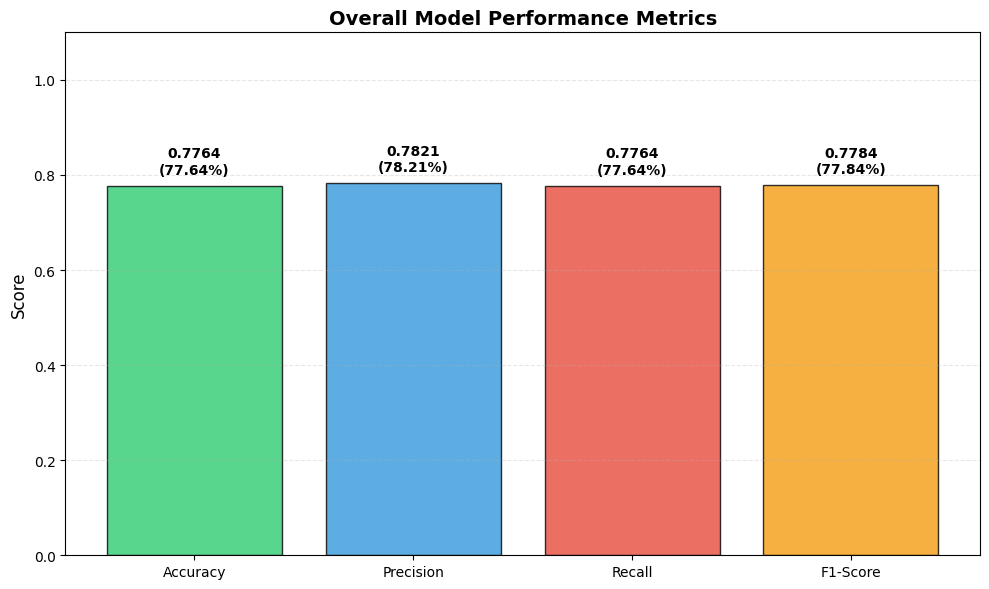

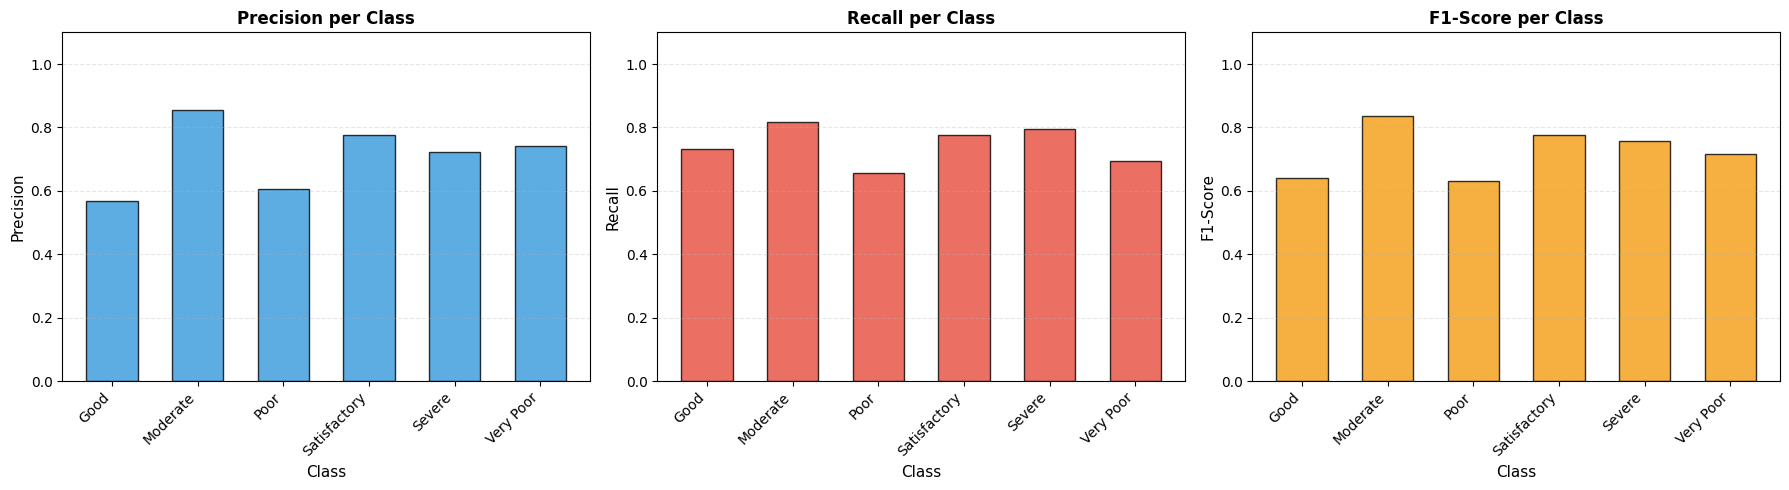

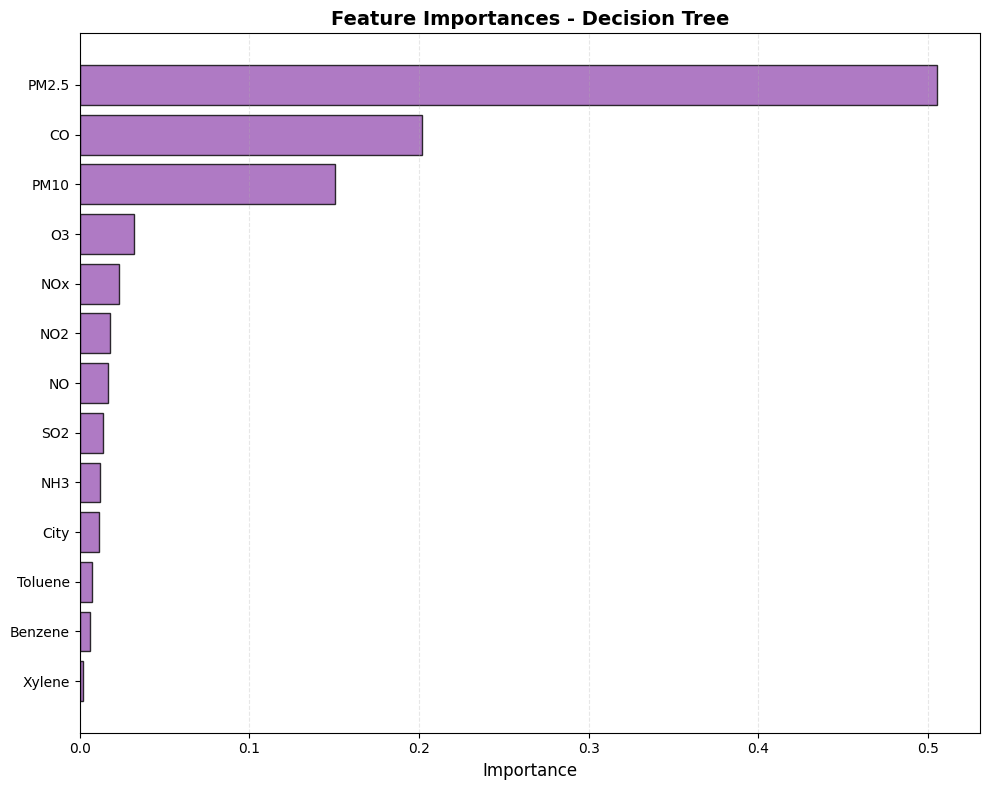


FEATURE IMPORTANCES


Feature  Importance
  PM2.5    0.505340
     CO    0.201848
   PM10    0.150487
     O3    0.032121
    NOx    0.023143
    NO2    0.017941
     NO    0.016595
    SO2    0.013912
    NH3    0.011893
   City    0.011515
Toluene    0.007106
Benzene    0.006107
 Xylene    0.001992


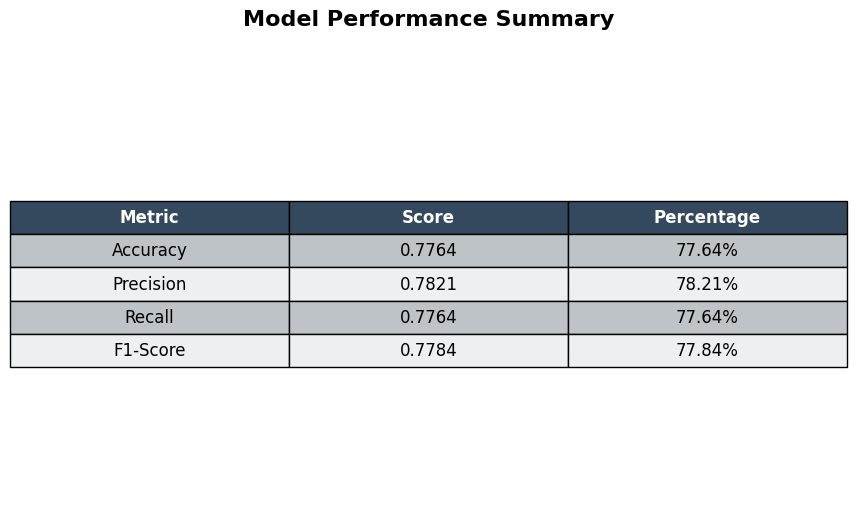


✅ EVALUATION COMPLETE


In [5]:
# Comprehensive Evaluation and Visualization
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
# Set style for better-looking plots
plt.style.use('default')  # Using default style for compatibility
sns.set_palette("husl")
# Make predictions
print("\n📊 Making predictions...")
y_pred = model.predict(X_test)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
# Per-class metrics
precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
# Print overall metrics
print("\n" + "="*80)
print("OVERALL METRICS")
print("="*80)
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
# Create metrics table
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)
metrics_df = pd.DataFrame({
    'Class': le.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
})
print("\n")
print(metrics_df.to_string(index=False))
# Classification Report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print("\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# Visualization 1: Confusion Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Decision Tree Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()
# Visualization 2: Metrics Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylim([0, 1.1])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Model Performance Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.4f}\n({value*100:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
# Visualization 3: Per-Class Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_pos = np.arange(len(le.classes_))
width = 0.6
axes[0].bar(x_pos, precision_per_class, width, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision per Class', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].bar(x_pos, recall_per_class, width, color='#e74c3c', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall per Class', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].bar(x_pos, f1_per_class, width, color='#f39c12', alpha=0.8, edgecolor='black')
axes[2].set_xlabel('Class', fontsize=11)
axes[2].set_ylabel('F1-Score', fontsize=11)
axes[2].set_title('F1-Score per Class', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[2].set_ylim([0, 1.1])
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
# Visualization 4: Feature Importances
if model.feature_importances_ is not None:
    feature_imp_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(feature_imp_df)), feature_imp_df['Importance'], 
             color='#9b59b6', alpha=0.8, edgecolor='black')
    plt.yticks(range(len(feature_imp_df)), feature_imp_df['Feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title('Feature Importances - Decision Tree', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("FEATURE IMPORTANCES")
    print("="*80)
    print("\n")
    print(feature_imp_df.to_string(index=False))
# Visualization 5: Metrics Summary Table (Visual)
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')
table_data = [
    ['Metric', 'Score', 'Percentage'],
    ['Accuracy', f'{accuracy:.4f}', f'{accuracy*100:.2f}%'],
    ['Precision', f'{precision:.4f}', f'{precision*100:.2f}%'],
    ['Recall', f'{recall:.4f}', f'{recall*100:.2f}%'],
    ['F1-Score', f'{f1:.4f}', f'{f1*100:.2f}%']
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center',
                colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)
# Style the header
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')
# Style the data rows
colors = ['#ecf0f1', '#bdc3c7']
for i in range(1, len(table_data)):
    for j in range(3):
        table[(i, j)].set_facecolor(colors[i % 2])
plt.title('Model Performance Summary', fontsize=16, fontweight='bold', pad=20)
plt.show()
print("\n" + "="*80)
print("✅ EVALUATION COMPLETE")
print("="*80)


In [6]:
# Save the model
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

import joblib

model_data = {
    'model': model,
    'label_encoder': le,
    'city_encoder': city_encoder,
    'scaler': scaler,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'feature_columns': feature_columns,
    'test_size': 0.3,
    'random_state': 0
}

model_data = {
    'model': model,
    'label_encoder': le,
    'city_encoder': city_encoder,
    'scaler': scaler,
    'feature_columns': feature_columns
}

joblib.dump(model_data, 'decision_tree_model.pkl')
print("Model saved as 'decision_tree_model.pkl'")

print(f"\n✅ Final Model: Decision Tree")
print(f"✅ Max depth: {max_depth}")
print(f"✅ Min samples split: {min_samples_split}")
print(f"✅ Features: {X_train_smote.shape[1]} features")
print(f"✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"✅ Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"✅ F1-Score: {f1:.4f} ({f1*100:.2f}%)")
print(f"✅ Number of classes: {len(le.classes_)}")

# Summary
print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)
print(f"Training samples: {X_train_smote.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of classes: {len(np.unique(y_train_smote))}")
print(f"Test size: 30%")
print(f"Preprocessing: Median imputation, StandardScaler, SMOTE (limited)")
print(f"Memory optimization: float32, sample limits applied")
print("="*80)



SAVING MODEL
Model saved as 'decision_tree_model.pkl'

✅ Final Model: Decision Tree
✅ Max depth: 10
✅ Min samples split: 5
✅ Features: 13 features
✅ Accuracy: 0.7764 (77.64%)
✅ Precision: 0.7821 (78.21%)
✅ Recall: 0.7764 (77.64%)
✅ F1-Score: 0.7784 (77.84%)
✅ Number of classes: 6

MODEL SUMMARY
Training samples: 10000
Test samples: 8860
Number of classes: 6
Test size: 30%
Preprocessing: Median imputation, StandardScaler, SMOTE (limited)
Memory optimization: float32, sample limits applied


In [7]:
# ============================================================================
# HELPER FUNCTION: Convert AQI to AQI_Bucket
# ============================================================================
def aqi_to_bucket(aqi):
    """
    Convert AQI value to AQI_Bucket category.
    Standard AQI categories:
    - Good: 0-50
    - Satisfactory: 51-100
    - Moderate: 101-200
    - Poor: 201-300
    - Very Poor: 301-400
    - Severe: 401-500
    """
    if pd.isna(aqi):
        return 'Moderate'
    aqi = float(aqi)
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'
# ============================================================================
# HELPER FUNCTION: Flexible Data Preprocessing
# ============================================================================
def preprocess_dataset(data, dataset_name="Dataset"):
    """
    Preprocess dataset with flexible column handling.
    Returns: X, y, le, city_encoder (if applicable), feature_columns
    """
    print(f"\n{'='*80}")
    print(f"PREPROCESSING: {dataset_name}")
    print(f"{'='*80}")
    
    # Make a copy to avoid modifying original
    df = data.copy()
    
    # Convert Date to datetime if present
    if 'Date' in df.columns:
        print("✓ Processing Date column...")
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Create AQI_Bucket from AQI if it doesn't exist
    if 'AQI_Bucket' not in df.columns and 'AQI' in df.columns:
        print("✓ Creating AQI_Bucket from AQI values...")
        df['AQI_Bucket'] = df['AQI'].apply(aqi_to_bucket)
    
    # Handle missing values
    print("\n✓ Processing missing values...")
    
    # Identify numeric columns (pollutants and other numeric features)
    numeric_cols = []
    pollutant_patterns = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 
                         'O3', 'Ozone', 'Benzene', 'Toluene', 'Xylene', 'AQI',
                         'temperature', 'humidity', 'wind_speed', 'traffic_density', 
                         'industrial_activity', 'Temperature', 'Humidity', 'Wind Speed']
    
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            # Check if it's a pollutant or numeric feature
            if any(pattern.lower() in col.lower() for pattern in pollutant_patterns):
                numeric_cols.append(col)
            elif col not in ['Date', 'City', 'Country', 'AQI_Bucket', 'Month', 'Year', 'Days']:
                numeric_cols.append(col)
    
    # Fill missing numeric values with median
    print(f"  Filling missing numeric values with median for {len(numeric_cols)} columns...")
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    
    # Fill missing AQI_Bucket
    if 'AQI_Bucket' in df.columns:
        df['AQI_Bucket'] = df['AQI_Bucket'].fillna('Moderate')
    
    print(f"  Missing values after handling: {df.isnull().sum().sum()}")
    
    # Encode categorical variables
    print("\n✓ Encoding categorical variables...")
    le = LabelEncoder()
    city_encoder = None
    
    # Encode City if present
    if 'City' in df.columns:
        city_encoder = LabelEncoder()
        df['City'] = city_encoder.fit_transform(df['City'].astype(str))
        print(f"  Number of unique cities: {len(city_encoder.classes_)}")
    
    # Encode Country if present (encode both City and Country if both exist)
    if 'Country' in df.columns:
        if city_encoder is None:
            city_encoder = LabelEncoder()
        # Create a separate encoder for Country if both exist, or reuse if only Country exists
        country_encoder = LabelEncoder()
        df['Country'] = country_encoder.fit_transform(df['Country'].astype(str))
        print(f"  Number of unique countries: {len(country_encoder.classes_)}")
    
    # Encode target (AQI_Bucket)
    if 'AQI_Bucket' in df.columns:
        df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'].astype(str))
        print(f"  Classes: {le.classes_}")
    else:
        raise ValueError("AQI_Bucket column not found and could not be created from AQI")
    
    # Prepare features
    print("\n✓ Preparing features...")
    
    # Define potential feature columns based on common patterns
    potential_features = []
    
    # Location features
    if 'City' in df.columns:
        potential_features.append('City')
    if 'Country' in df.columns:
        potential_features.append('Country')
    
    # Pollutant features (handle different naming conventions)
    pollutant_mappings = {
        'PM2.5': ['PM2.5', 'PM2.5 (Âµg/mÂ³)', 'PM2.5 (µg/m³)'],
        'PM10': ['PM10', 'PM10 (Âµg/mÂ³)', 'PM10 (µg/m³)'],
        'NO2': ['NO2', 'NO2 (ppb)'],
        'SO2': ['SO2', 'SO2 (ppb)'],
        'CO': ['CO', 'CO (ppm)'],
        'O3': ['O3', 'O3 (ppb)', 'Ozone'],
        'NO': ['NO'],
        'NOx': ['NOx'],
        'NH3': ['NH3'],
        'Benzene': ['Benzene'],
        'Toluene': ['Toluene'],
        'Xylene': ['Xylene']
    }
    
    # Environmental features
    env_features = ['temperature', 'Temperature (Â°C)', 'Temperature (°C)',
                   'humidity', 'Humidity (%)', 'Humidity',
                   'wind_speed', 'Wind Speed (m/s)', 'Wind Speed',
                   'traffic_density', 'industrial_activity']
    
    # Temporal features (optional)
    temporal_features = ['Month', 'Year', 'Days', 'Holidays_Count']
    
    # Collect available features
    feature_columns = []
    for col in df.columns:
        # Skip target and AQI
        if col in ['AQI', 'AQI_Bucket']:
            continue
        # Skip Date (we'll extract temporal features if needed)
        if col == 'Date':
            continue
        # Include if it's a known feature
        if (col in potential_features or 
            any(col in patterns for patterns in pollutant_mappings.values()) or
            col in env_features or
            col in temporal_features):
            feature_columns.append(col)
        # Include other numeric columns that aren't Date
        elif df[col].dtype in ['int64', 'float64'] and col not in ['Date']:
            feature_columns.append(col)
    
    # Remove duplicates and ensure columns exist
    feature_columns = list(dict.fromkeys(feature_columns))  # Preserve order, remove duplicates
    feature_columns = [col for col in feature_columns if col in df.columns]
    
    # Ensure all feature columns are numeric (encode any remaining string/object columns)
    print("  Ensuring all features are numeric...")
    columns_to_remove = []
    for col in feature_columns:
        if df[col].dtype == 'object' or (hasattr(df[col].dtype, 'name') and df[col].dtype.name == 'category'):
            try:
                # Try to convert to numeric first
                df[col] = pd.to_numeric(df[col], errors='coerce')
                if df[col].isna().all():
                    # If all NaN, encode it
                    print(f"    Encoding column: {col}")
                    encoder = LabelEncoder()
                    df[col] = encoder.fit_transform(df[col].fillna('Unknown').astype(str))
                else:
                    # Fill NaN with median
                    df[col] = df[col].fillna(df[col].median())
            except:
                # If conversion fails, encode it
                print(f"    Encoding column: {col}")
                encoder = LabelEncoder()
                df[col] = encoder.fit_transform(df[col].astype(str))
    
    # Remove any columns that are still non-numeric
    for col in feature_columns[:]:  # Use slice copy to modify while iterating
        if df[col].dtype not in ['int64', 'float64', 'int32', 'float32', 'int', 'float']:
            print(f"  ⚠️  Removing non-numeric column: {col}")
            columns_to_remove.append(col)
    
    feature_columns = [col for col in feature_columns if col not in columns_to_remove]
    
    # Final verification: ensure all features are numeric
    print("  Final verification of feature types...")
    final_feature_columns = []
    for col in feature_columns:
        # Check if column is numeric
        if pd.api.types.is_numeric_dtype(df[col]):
            final_feature_columns.append(col)
        else:
            print(f"  ⚠️  Skipping non-numeric column: {col} (dtype: {df[col].dtype})")
            # Try one more time to convert
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                if pd.api.types.is_numeric_dtype(df[col]):
                    final_feature_columns.append(col)
                    df[col] = df[col].fillna(df[col].median())
                    print(f"    ✓ Converted {col} to numeric")
            except:
                print(f"    ✗ Could not convert {col}, removing from features")
    
    feature_columns = final_feature_columns
    
    if len(feature_columns) == 0:
        raise ValueError("No numeric features found! Please check your data preprocessing.")
    
    print(f"  ✓ Final feature columns ({len(feature_columns)}): {feature_columns}")
    print(f"  Total features: {len(feature_columns)}")
    
    # Extract features and target
    X = df[feature_columns].values.astype(np.float32)  # Convert to float32 directly
    y = df['AQI_Bucket'].values
    
    return X, y, le, city_encoder, feature_columns
# ============================================================================
# HELPER FUNCTION: Train and Evaluate Model
# ============================================================================
def train_and_evaluate_model(X_train, y_train, X_test, y_test, feature_columns, 
                            le, dataset_name, max_depth=10, min_samples_split=5):
    """
    Train and evaluate Decision Tree model.
    Returns: model, accuracy, precision, recall, f1, y_pred
    """
    print(f"\n{'='*80}")
    print(f"TRAINING AND EVALUATION: {dataset_name}")
    print(f"{'='*80}")
    
    # Apply SMOTE if needed
    print("\n✓ Applying SMOTE for data balancing...")
    MAX_SAMPLES_PER_CLASS = 3000
    
    try:
        smote = SimpleSMOTE(random_state=42, max_samples_per_class=MAX_SAMPLES_PER_CLASS)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
        print(f"  ✓ SMOTE applied successfully")
    except Exception as e:
        print(f"  ⚠️  SMOTE failed: {e}. Using original data...")
        X_train_smote, y_train_smote = X_train, y_train
    
    # Convert to float32
    X_train_smote = X_train_smote.astype(np.float32)
    X_test = X_test.astype(np.float32)
    
    # Limit samples if too large
    MAX_TRAIN_SAMPLES = 10000
    if len(X_train_smote) > MAX_TRAIN_SAMPLES:
        print(f"  Limiting to {MAX_TRAIN_SAMPLES} samples...")
        X_train_smote, _, y_train_smote, _ = train_test_split(
            X_train_smote, y_train_smote,
            train_size=MAX_TRAIN_SAMPLES,
            random_state=42,
            stratify=y_train_smote
        )
    
    # Scale features
    print("\n✓ Scaling features...")
    scaler = StandardScaler()
    X_train_smote = scaler.fit_transform(X_train_smote).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)
    
    # Train model
    print(f"\n🚀 Training Decision Tree...")
    model = DecisionTree(max_depth=max_depth, min_samples_split=min_samples_split, verbose=True)
    model.fit(X_train_smote, y_train_smote)
    
    # Make predictions
    print("\n📊 Making predictions...")
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n🎯 Results for {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    
    return model, accuracy, precision, recall, f1, y_pred, scaler, X_train_smote, y_train_smote



DATASET 2: DELHI AIR QUALITY DATASET
📁 Loading from: delhi_air_quality_dataset.csv
✓ Dataset loaded: (1461, 12)

PREPROCESSING: Delhi Air Quality
✓ Processing Date column...
✓ Creating AQI_Bucket from AQI values...

✓ Processing missing values...
  Filling missing numeric values with median for 8 columns...
  Missing values after handling: 0

✓ Encoding categorical variables...
  Classes: ['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']

✓ Preparing features...
  Ensuring all features are numeric...
  Final verification of feature types...
  ✓ Final feature columns (10): ['Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
  Total features: 10

✓ Splitting dataset...
  Train samples: 1022
  Test samples: 439

TRAINING AND EVALUATION: Delhi Air Quality

✓ Applying SMOTE for data balancing...
  ✓ SMOTE applied successfully

✓ Scaling features...

🚀 Training Decision Tree...
Training Decision Tree: max_depth=10, min_samples_split=5
✓ Tra

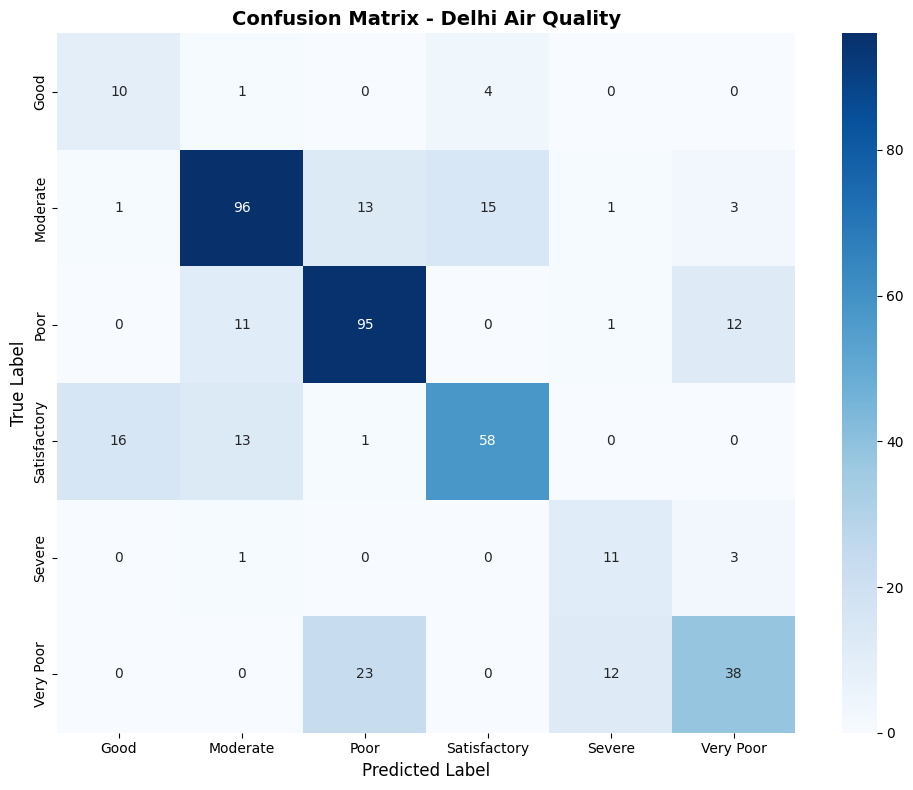

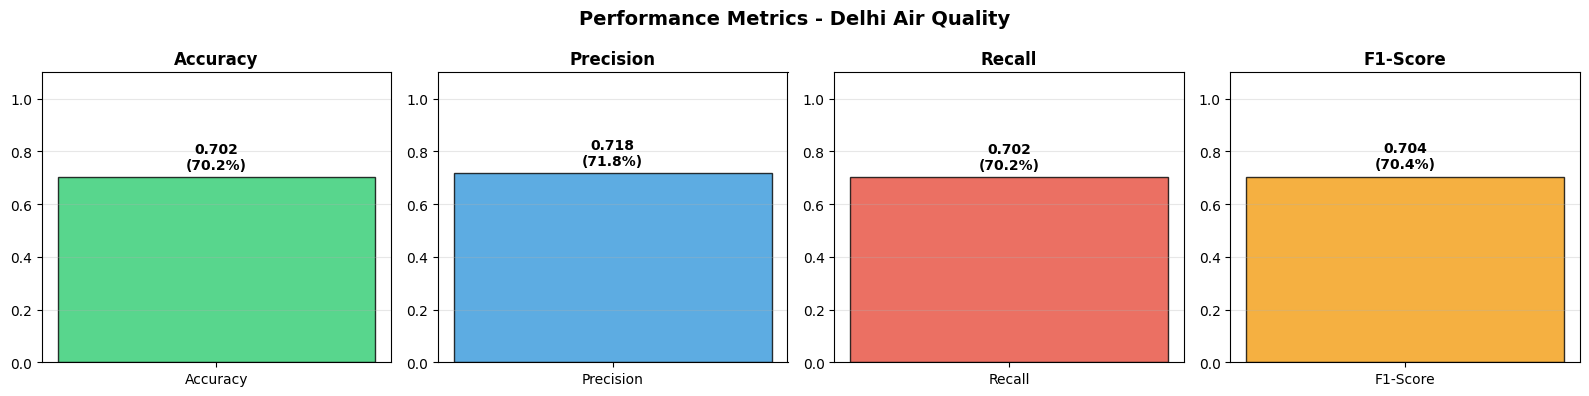

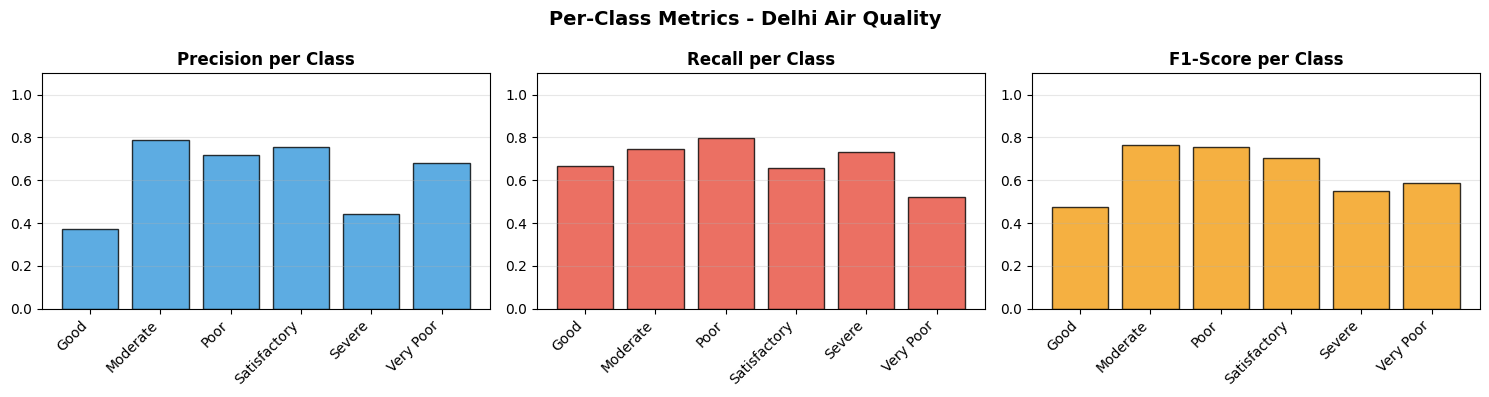

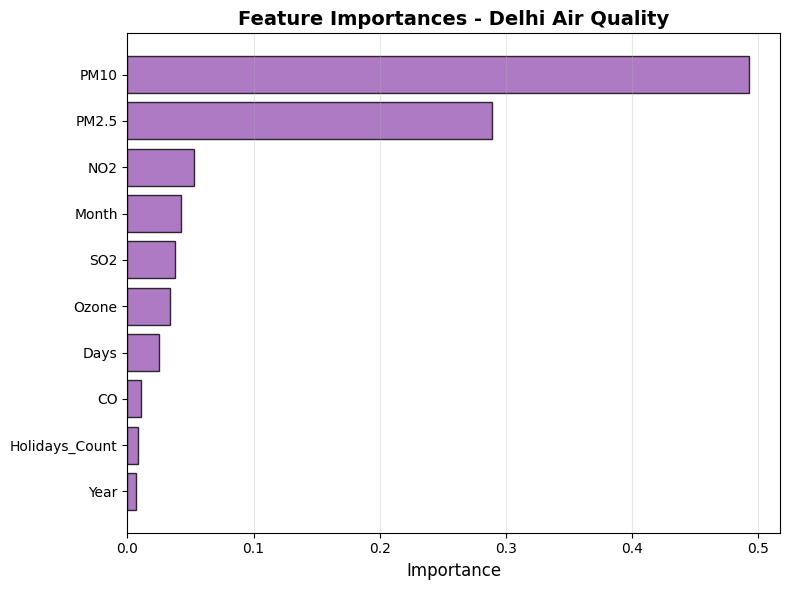


Feature Importances:
       Feature  Importance
          PM10    0.492660
         PM2.5    0.288987
           NO2    0.052928
         Month    0.042737
           SO2    0.037631
         Ozone    0.033607
          Days    0.025011
            CO    0.010892
Holidays_Count    0.008431
          Year    0.007116

✅ Delhi Air Quality - EVALUATION COMPLETE


In [8]:
# ============================================================================
# DATASET 2: Delhi Air Quality Dataset
# ============================================================================

print("\n" + "="*80)
print("DATASET 2: DELHI AIR QUALITY DATASET")
print("="*80)

# Load dataset
dataset_name = "Delhi Air Quality"
csv_file = "delhi_air_quality_dataset.csv"

try:
    print(f"📁 Loading from: {csv_file}")
    data_delhi = pd.read_csv(csv_file)
    
    print(f"✓ Dataset loaded: {data_delhi.shape}")
    
    # Preprocess
    X_delhi, y_delhi, le_delhi, city_encoder_delhi, feature_columns_delhi = preprocess_dataset(
        data_delhi, dataset_name=dataset_name
    )
    
    # Split dataset
    print("\n✓ Splitting dataset...")
    X_train_delhi, X_test_delhi, y_train_delhi, y_test_delhi = train_test_split(
        X_delhi, y_delhi, test_size=0.3, random_state=0
    )
    
    print(f"  Train samples: {len(X_train_delhi)}")
    print(f"  Test samples: {len(X_test_delhi)}")
    
    # Train and evaluate
    model_delhi, acc_delhi, prec_delhi, rec_delhi, f1_delhi, y_pred_delhi, scaler_delhi, X_train_smote_delhi, y_train_smote_delhi = train_and_evaluate_model(
        X_train_delhi, y_train_delhi, X_test_delhi, y_test_delhi,
        feature_columns_delhi, le_delhi, dataset_name,
        max_depth=10, min_samples_split=5
    )
    
    # Comprehensive Evaluation
    print("\n" + "="*80)
    print(f"COMPREHENSIVE EVALUATION: {dataset_name}")
    print("="*80)
    
    from sklearn.metrics import classification_report, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Per-class metrics
    precision_per_class = precision_score(y_test_delhi, y_pred_delhi, average=None, zero_division=0)
    recall_per_class = recall_score(y_test_delhi, y_pred_delhi, average=None, zero_division=0)
    f1_per_class = f1_score(y_test_delhi, y_pred_delhi, average=None, zero_division=0)
    
    # Create metrics DataFrame
    metrics_df_delhi = pd.DataFrame({
        'Class': le_delhi.classes_,
        'Precision': precision_per_class,
        'Recall': recall_per_class,
        'F1-Score': f1_per_class
    })
    
    print("\nPer-Class Metrics:")
    print(metrics_df_delhi.to_string(index=False))
    
    print("\nClassification Report:")
    print(classification_report(y_test_delhi, y_pred_delhi, target_names=le_delhi.classes_))
    
    # Visualizations
    cm_delhi = confusion_matrix(y_test_delhi, y_pred_delhi)
    
    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_delhi, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_delhi.classes_, yticklabels=le_delhi.classes_)
    plt.title(f'Confusion Matrix - {dataset_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Metrics Bar Chart
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    metrics_data = [
        ('Accuracy', acc_delhi, '#2ecc71'),
        ('Precision', prec_delhi, '#3498db'),
        ('Recall', rec_delhi, '#e74c3c'),
        ('F1-Score', f1_delhi, '#f39c12')
    ]
    
    for idx, (name, value, color) in enumerate(metrics_data):
        axes[idx].bar([name], [value], color=color, alpha=0.8, edgecolor='black')
        axes[idx].set_ylim([0, 1.1])
        axes[idx].set_title(name, fontweight='bold')
        axes[idx].text(0, value + 0.02, f'{value:.3f}\n({value*100:.1f}%)',
                      ha='center', va='bottom', fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'Performance Metrics - {dataset_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Per-class metrics
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x_pos = np.arange(len(le_delhi.classes_))
    
    axes[0].bar(x_pos, precision_per_class, color='#3498db', alpha=0.8, edgecolor='black')
    axes[0].set_title('Precision per Class', fontweight='bold')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
    axes[0].set_ylim([0, 1.1])
    axes[0].grid(axis='y', alpha=0.3)
    
    axes[1].bar(x_pos, recall_per_class, color='#e74c3c', alpha=0.8, edgecolor='black')
    axes[1].set_title('Recall per Class', fontweight='bold')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
    axes[1].set_ylim([0, 1.1])
    axes[1].grid(axis='y', alpha=0.3)
    
    axes[2].bar(x_pos, f1_per_class, color='#f39c12', alpha=0.8, edgecolor='black')
    axes[2].set_title('F1-Score per Class', fontweight='bold')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(le_delhi.classes_, rotation=45, ha='right')
    axes[2].set_ylim([0, 1.1])
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'Per-Class Metrics - {dataset_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature importances
    if model_delhi.feature_importances_ is not None:
        feature_imp_df_delhi = pd.DataFrame({
            'Feature': feature_columns_delhi,
            'Importance': model_delhi.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(8, 6))
        plt.barh(range(len(feature_imp_df_delhi)), feature_imp_df_delhi['Importance'],
                color='#9b59b6', alpha=0.8, edgecolor='black')
        plt.yticks(range(len(feature_imp_df_delhi)), feature_imp_df_delhi['Feature'])
        plt.xlabel('Importance', fontsize=12)
        plt.title(f'Feature Importances - {dataset_name}', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\nFeature Importances:")
        print(feature_imp_df_delhi.to_string(index=False))
    
    print("\n" + "="*80)
    print(f"✅ {dataset_name} - EVALUATION COMPLETE")
    print("="*80)
    
except Exception as e:
    print(f"\n❌ Error processing {dataset_name}: {e}")
    import traceback
    traceback.print_exc()


COMPARISON: ALL DATASETS PERFORMANCE SUMMARY

PERFORMANCE COMPARISON TABLE


          Dataset  Accuracy  Precision   Recall  F1-Score  Train Samples  Test Samples  Features
 City Day Dataset  0.776411   0.782144 0.776411  0.778381          10000          8860        13
Delhi Air Quality  0.701595   0.717834 0.701595  0.703928           2004           439        10


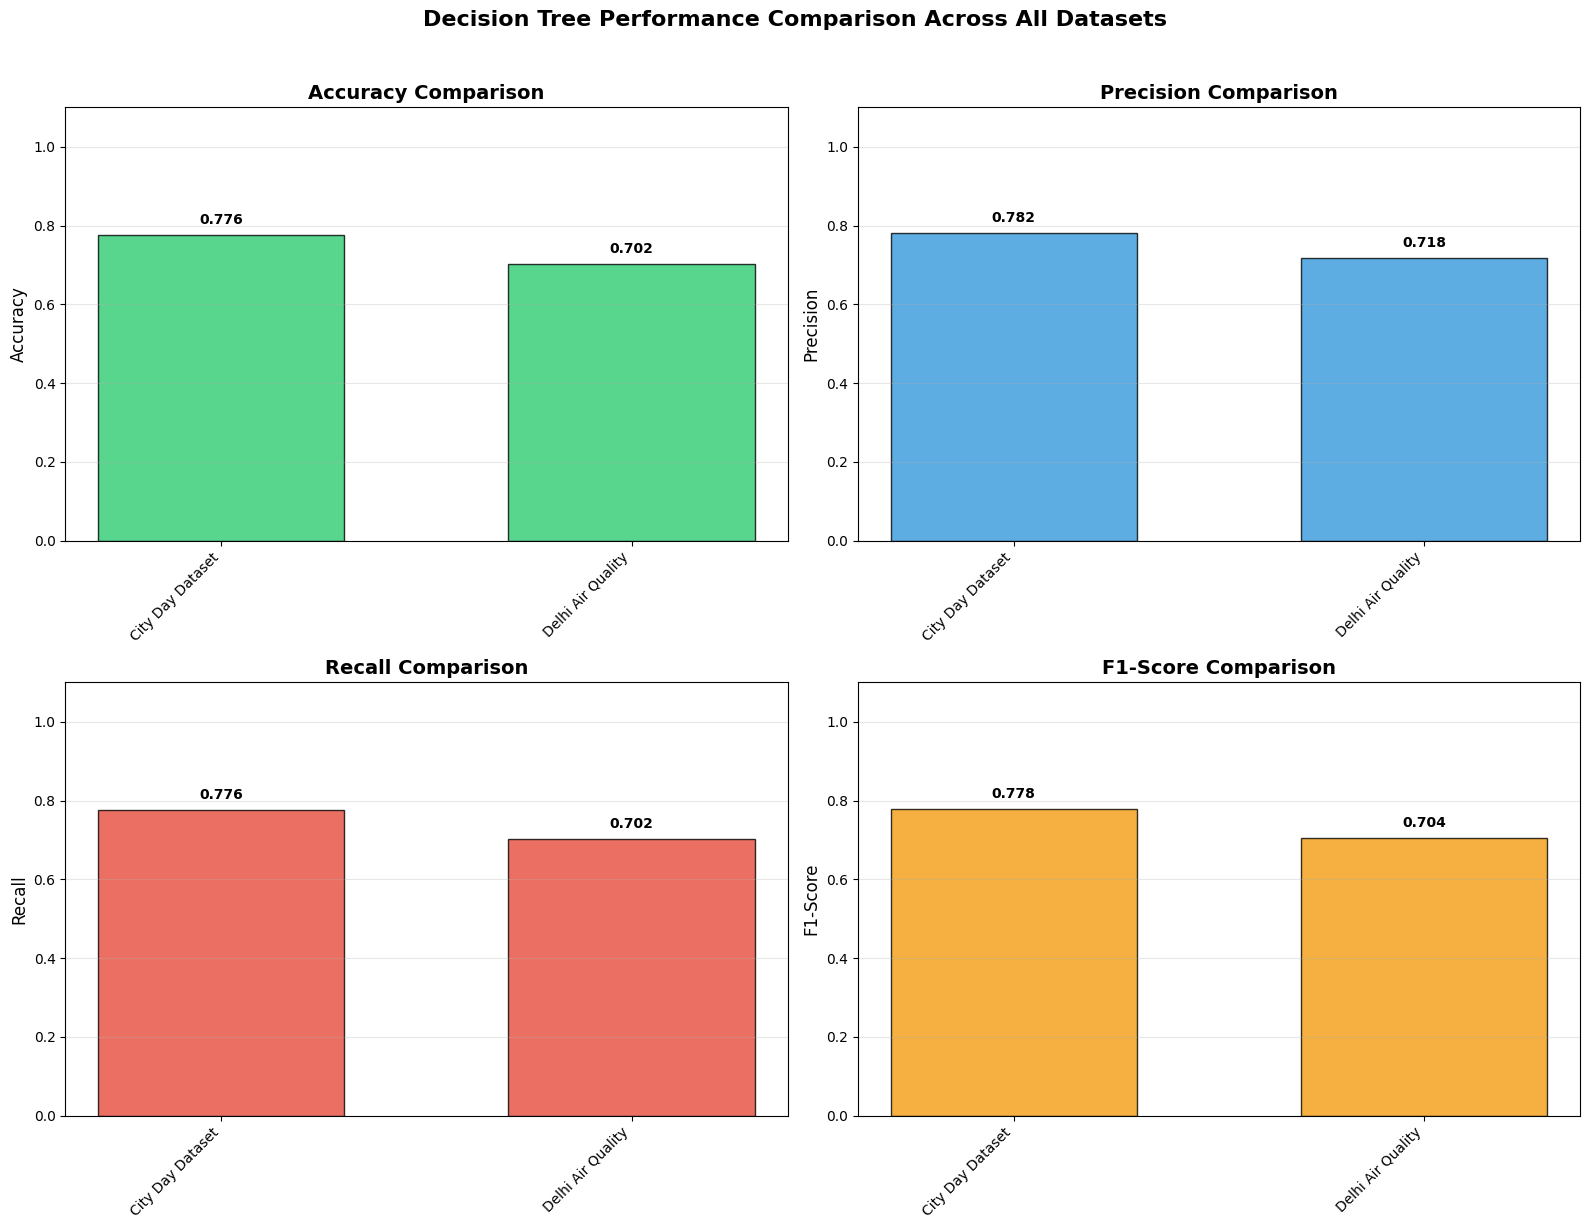

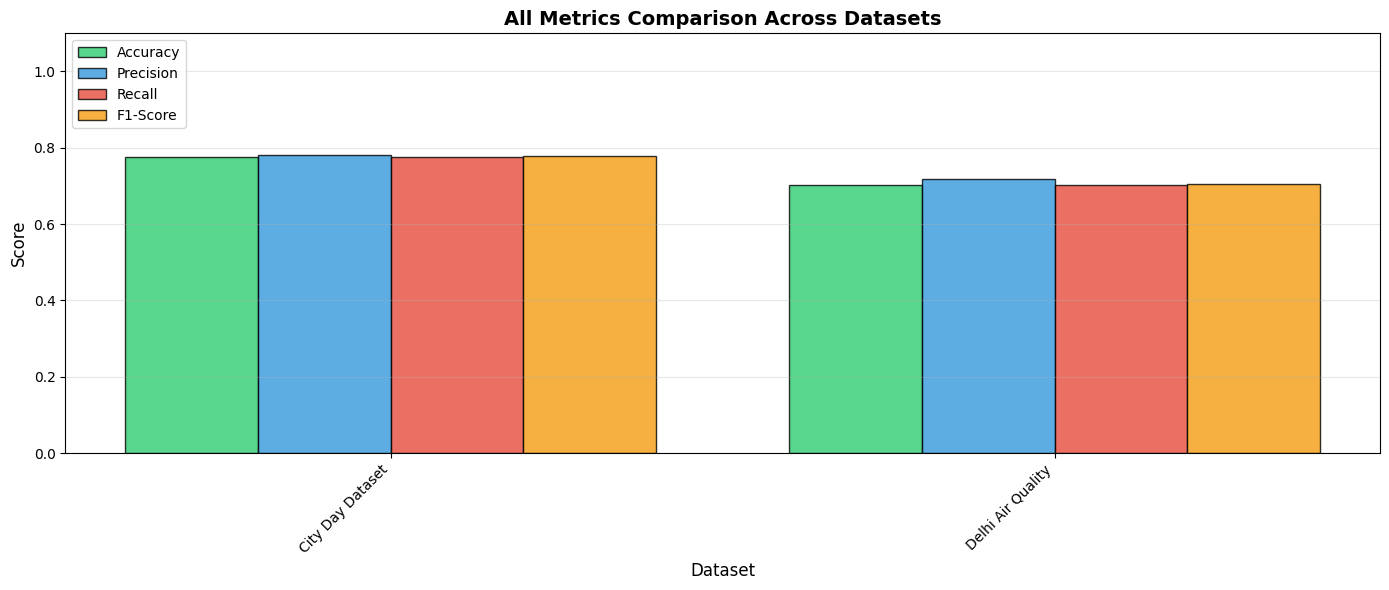

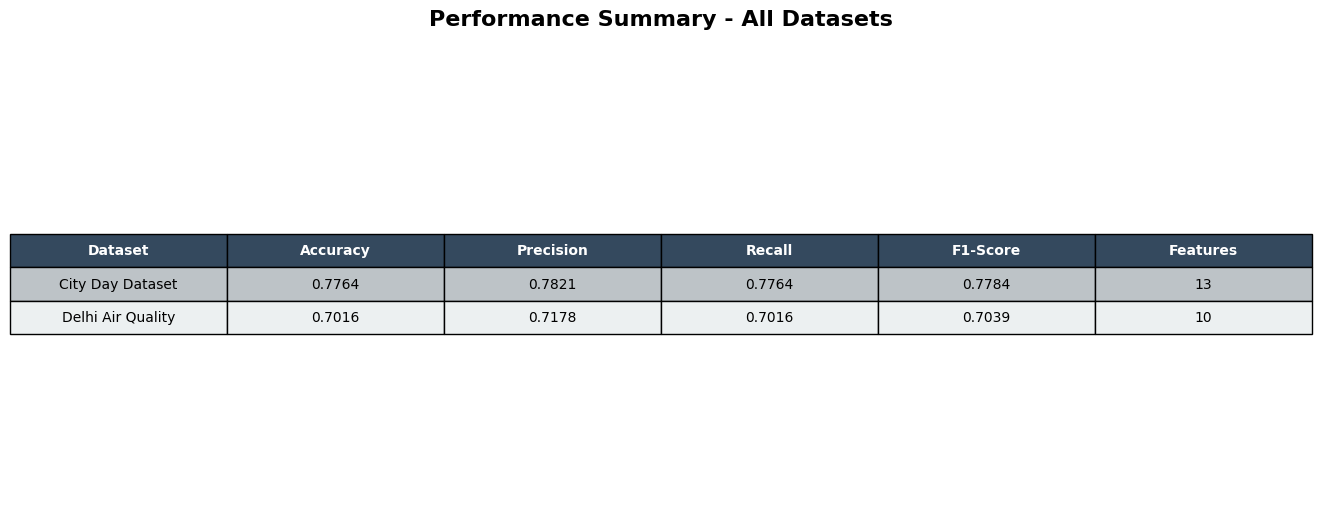


✅ COMPARISON COMPLETE


In [9]:
# ============================================================================
# COMPARISON: All Datasets Performance Summary
# ============================================================================

print("\n" + "="*80)
print("COMPARISON: ALL DATASETS PERFORMANCE SUMMARY")
print("="*80)

# Collect results from all datasets
results_summary = []

# Original dataset (city_day_dataset.csv)
try:
    results_summary.append({
        'Dataset': 'City Day Dataset',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train Samples': len(X_train_smote),
        'Test Samples': len(X_test),
        'Features': len(feature_columns)
    })
except:
    pass

# Delhi dataset
try:
    results_summary.append({
        'Dataset': 'Delhi Air Quality',
        'Accuracy': acc_delhi,
        'Precision': prec_delhi,
        'Recall': rec_delhi,
        'F1-Score': f1_delhi,
        'Train Samples': len(X_train_smote_delhi),
        'Test Samples': len(X_test_delhi),
        'Features': len(feature_columns_delhi)
    })
except:
    pass

if results_summary:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(results_summary)
    
    print("\n" + "="*80)
    print("PERFORMANCE COMPARISON TABLE")
    print("="*80)
    print("\n")
    print(comparison_df.to_string(index=False))
    
    # Visualization: Comparison Bar Chart
    if len(results_summary) > 1:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        datasets = comparison_df['Dataset'].values
        x_pos = np.arange(len(datasets))
        width = 0.6
        
        # Accuracy comparison
        axes[0, 0].bar(x_pos, comparison_df['Accuracy'], width, color='#2ecc71', alpha=0.8, edgecolor='black')
        axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylabel('Accuracy', fontsize=12)
        axes[0, 0].set_xticks(x_pos)
        axes[0, 0].set_xticklabels(datasets, rotation=45, ha='right')
        axes[0, 0].set_ylim([0, 1.1])
        axes[0, 0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['Accuracy']):
            axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Precision comparison
        axes[0, 1].bar(x_pos, comparison_df['Precision'], width, color='#3498db', alpha=0.8, edgecolor='black')
        axes[0, 1].set_title('Precision Comparison', fontsize=14, fontweight='bold')
        axes[0, 1].set_ylabel('Precision', fontsize=12)
        axes[0, 1].set_xticks(x_pos)
        axes[0, 1].set_xticklabels(datasets, rotation=45, ha='right')
        axes[0, 1].set_ylim([0, 1.1])
        axes[0, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['Precision']):
            axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Recall comparison
        axes[1, 0].bar(x_pos, comparison_df['Recall'], width, color='#e74c3c', alpha=0.8, edgecolor='black')
        axes[1, 0].set_title('Recall Comparison', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('Recall', fontsize=12)
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(datasets, rotation=45, ha='right')
        axes[1, 0].set_ylim([0, 1.1])
        axes[1, 0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['Recall']):
            axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # F1-Score comparison
        axes[1, 1].bar(x_pos, comparison_df['F1-Score'], width, color='#f39c12', alpha=0.8, edgecolor='black')
        axes[1, 1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('F1-Score', fontsize=12)
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(datasets, rotation=45, ha='right')
        axes[1, 1].set_ylim([0, 1.1])
        axes[1, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(comparison_df['F1-Score']):
            axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.suptitle('Decision Tree Performance Comparison Across All Datasets', 
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Combined metrics comparison
        fig, ax = plt.subplots(figsize=(14, 6))
        x = np.arange(len(datasets))
        width = 0.2
        
        metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        colors_combined = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
        
        for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_combined)):
            offset = (i - 1.5) * width
            ax.bar(x + offset, comparison_df[metric], width, label=metric, 
                  color=color, alpha=0.8, edgecolor='black')
        
        ax.set_xlabel('Dataset', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_title('All Metrics Comparison Across Datasets', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.legend(loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Summary table visualization
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.axis('tight')
        ax.axis('off')
        
        # Prepare table data
        table_data = [['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Features']]
        for _, row in comparison_df.iterrows():
            table_data.append([
                row['Dataset'],
                f"{row['Accuracy']:.4f}",
                f"{row['Precision']:.4f}",
                f"{row['Recall']:.4f}",
                f"{row['F1-Score']:.4f}",
                str(int(row['Features']))
            ])
        
        table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                        cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 2)
        
        # Style the header
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#34495e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Style the data rows
        colors_table = ['#ecf0f1', '#bdc3c7']
        for i in range(1, len(table_data)):
            for j in range(len(table_data[0])):
                table[(i, j)].set_facecolor(colors_table[i % 2])
        
        plt.title('Performance Summary - All Datasets', fontsize=16, fontweight='bold', pad=20)
        plt.show()
    
    print("\n" + "="*80)
    print("✅ COMPARISON COMPLETE")
    print("="*80)
else:
    print("\n⚠️  No datasets were successfully processed for comparison.")
